# Лабораторная работа №4
### 6132 Казаков Павел
### Вариант 12

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Callable

## 1. Считать цветное rgb изображение. Преобразовать в градации серого

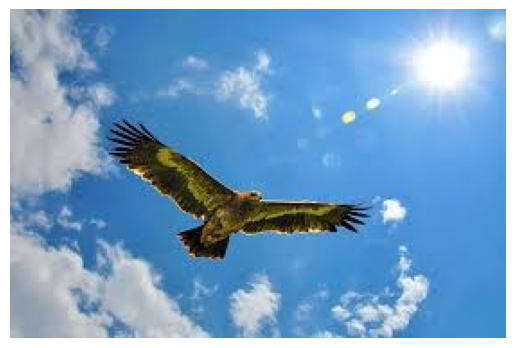

In [2]:
img = cv2.imread("images/eagle.jpg")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [3]:
def gray(img:np.ndarray, coef:np.ndarray):
  return np.round(np.dot(img, coef)).astype(np.uint8)

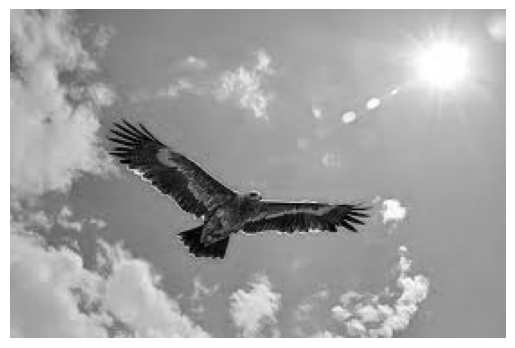

In [4]:
gray_img = gray(img, coef=np.array([0.2126, 0.7152, 0.0722]))

plt.imshow(gray_img, cmap="gray")
plt.axis("off")
plt.show()

## 2. Сделать выделение контуров методом простого градиента. В качестве значения модуля градиента использовать указанный в вариантах метод

In [5]:
def slide(x:np.ndarray, y:np.ndarray, 
         core:Callable[[np.ndarray, np.ndarray], int],
         pad_value:int=0) -> np.ndarray:
    M, N = x.shape

    top, left = (int(y.shape[0] % 2 == 0), int(y.shape[1] % 2 == 0))
    y = np.pad(y, ((0, top),(0, left)))

    top, left = np.array(y.shape) // 2
    x = np.pad(x, ((top, top),(left, left)), constant_values=pad_value)

    z = np.empty((M, N), dtype=np.int32)
    for m in range(M):
        for n in range(N):
            z[m, n] = core(x[m:m+y.shape[0],n:n+y.shape[1]], y)

    return z

In [6]:
def conv_core(x:np.ndarray, y:np.ndarray) -> int:
    y = np.rot90(y, 2)
    return int(round(np.sum(x*y)))

def conv_filter(x:np.ndarray, y:np.ndarray) -> np.ndarray:
    return slide(x, y, conv_core)

In [7]:
def bin(x:np.ndarray, threshold:int=50) -> np.ndarray:
  return np.where(x > threshold, 1, 0)

In [8]:
w1 = np.array([[-1, 1, 0]])
w2 = w1.T

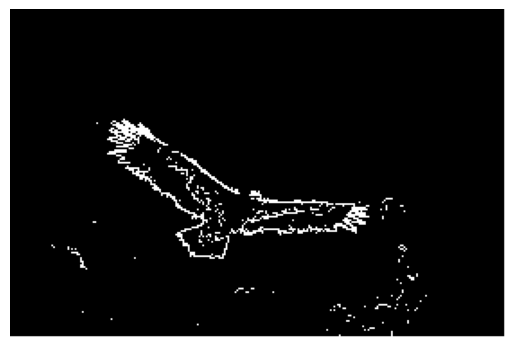

In [9]:
s1 = conv_filter(gray_img, w1)
s2 = conv_filter(gray_img, w2)

e = np.maximum(np.abs(s1), np.abs(s2))
grad_contour = bin(e, threshold=50)

plt.imshow(grad_contour, cmap="gray")
plt.axis("off")
plt.show()

## 3. Сделать выделение контуров методом по вариантам

In [10]:
w1 = np.array([[-1,-2,-1],
               [0, 0, 0],
               [1, 2, 1]])

w2 = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]])

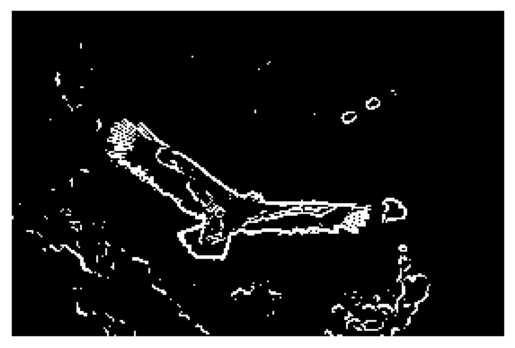

In [11]:
s1 = conv_filter(gray_img, w1)
s2 = conv_filter(gray_img, w2)

e = np.sqrt(s1**2 + s2**2)
sob_contour = bin(e, threshold=200)

plt.imshow(sob_contour, cmap="gray")
plt.axis("off")
plt.show()

## 4. Сделать выделение контуров методом с согласованием. Тип функции аппроксимации и размер окна указан по вариантам

In [12]:
w = 1/3 * np.array([[2, -1, 2],
                    [-1,-4,-1],
                    [2, -1, 2]])

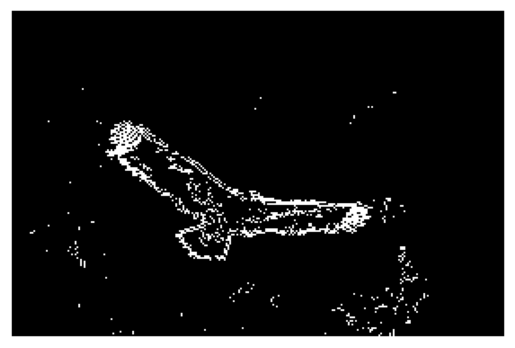

In [13]:
s = conv_filter(gray_img, w)

e = np.abs(s)
two_contour = bin(e, threshold=50)

plt.imshow(two_contour, cmap="gray")
plt.axis("off")
plt.show()

## 5. Сделать выделение контуров методом Canny (Функция OpenCV)

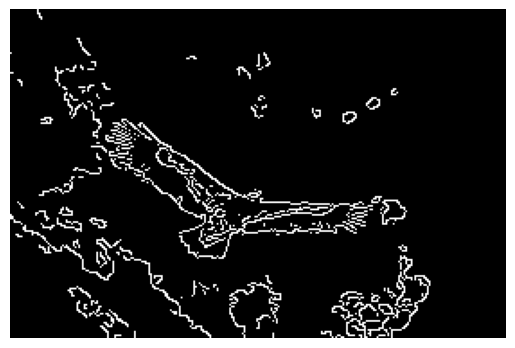

In [14]:
canny_contour = cv2.Canny(gray_img, threshold1=150, threshold2=200, apertureSize=3, L2gradient=False)

plt.imshow(canny_contour, cmap="gray")
plt.axis("off")
plt.show()